In [1]:
### Importar librerías y cargar datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta absoluta o relativa
df = pd.read_csv(r"C:\Proyectos\pet-ecg-quality-ml\data\raw\dataset.csv")

df.head()

,_id,ecg_path,duration,pet_id,breeds,weight,age,segments_br,segments_hr,ecg_pulses,bad_ecg
0,62271dc2b9baee839b0c1e99,ecg_data/62271dc2b9baee839b0c1e99.wav,300.12,14,boxer,34.0,4.5,"[{'deb': 200.0, 'fin': 240.0, 'value': 13.24}]",NaN,"[0.98, 2.51, 2.82, 3.39, 4.04, 4.65, 5.57, 6.5...","[(2.0, 132.0), (184.0, 298.1231)]"
1,62271ea0be903091edb2bf09,ecg_data/62271ea0be903091edb2bf09.wav,300.08,14,boxer,34.0,4.5,"[{'deb': 240.0, 'fin': 280.0, 'value': 12.34},...",NaN,"[0.64, 1.28, 2.06, 2.37, 2.79, 3.7, 4.41, 5.3,...","[(2.0, 298.0769)]"
2,622723bebe903091edb2bf0b,ecg_data/622723bebe903091edb2bf0b.wav,300.08,14,boxer,34.0,4.5,"[{'deb': 210.0, 'fin': 250.0, 'value': 12.01},...","[{'deb': 90.0, 'fin': 110.0, 'value': 56.39}, ...","[0.93, 1.14, 1.94, 2.95, 3.82, 4.44, 5.02, 6.3...","[(2.0, 80.0), (132.0, 158.0)]"
3,622776fabe903091edb2bf0d,ecg_data/622776fabe903091edb2bf0d.wav,300.14,14,boxer,34.0,4.5,"[{'deb': 50.0, 'fin': 90.0, 'value': 13.13}]","[{'deb': 240.0, 'fin': 260.0, 'value': 52.43},...","[0.83, 1.84, 2.62, 3.33, 5.25, 6.9, 7.77, 8.43...","[(28.0, 106.0), (158.0, 210.0), (262.0, 298.14..."
4,622799e5ea79f8f9cc02b284,ecg_data/622799e5ea79f8f9cc02b284.wav,300.12,14,boxer,34.0,4.5,"[{'deb': 100.0, 'fin': 140.0, 'value': 13.99}]","[{'deb': 250.0, 'fin': 270.0, 'value': 46.81},...","[1.18, 2.33, 3.75, 5.42, 6.6, 7.76, 8.84, 9.94...","[(28.0, 236.0)]"


In [2]:
### EDA rápido

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1123 entries, 0 to 1122
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   _id          1123 non-null   object 
 1   ecg_path     1102 non-null   object 
 2   duration     1123 non-null   float64
 3   pet_id       1123 non-null   int64  
 4   breeds       1123 non-null   object 
 5   weight       1123 non-null   float64
 6   age          1123 non-null   float64
 7   segments_br  1063 non-null   object 
 8   segments_hr  968 non-null    object 
 9   ecg_pulses   1102 non-null   object 
 10  bad_ecg      1123 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 96.6+ KB


In [3]:
df.describe(include="all")

,_id,ecg_path,duration,pet_id,breeds,weight,age,segments_br,segments_hr,ecg_pulses,bad_ecg
count,1123,1102,1123.000000,1123.000000,1123,1123.000000,1123.000000,1063,968,1102,1123
unique,1123,1102,NaN,NaN,25,NaN,NaN,1057,968,1101,227
top,62271dc2b9baee839b0c1e99,ecg_data/62271dc2b9baee839b0c1e99.wav,NaN,NaN,unknown,NaN,NaN,"[{'deb': 46.4, 'fin': 87.0, 'value': 16.33}]","[{'deb': 90.0, 'fin': 110.0, 'value': 56.39}, ...","[1.08, 1.89, 2.55, 3.39, 4.85, 5.7, 6.35, 7.9,...",[]
freq,1,1,NaN,NaN,117,NaN,NaN,2,1,2,675
mean,NaN,NaN,298.417409,15.587711,NaN,21.999110,3.585040,NaN,NaN,NaN,NaN
std,NaN,NaN,47.988343,9.843613,NaN,8.304262,2.108016,NaN,NaN,NaN,NaN
min,NaN,NaN,21.980000,0.000000,NaN,9.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,300.090000,7.000000,NaN,15.400000,2.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,300.130000,15.000000,NaN,24.000000,3.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,300.170000,24.000000,NaN,27.000000,4.500000,NaN,NaN,NaN,NaN


In [4]:
### Distribución del target:

df["bad_ecg"].value_counts(normalize=True)

bad_ecg
[]                                                    0.601069
[(2.0, 28.0)]                                         0.020481
[(2.0, 298.1462)]                                     0.016028
[(54.0, 80.0)]                                        0.014248
[(2.0, 54.0)]                                         0.013357
                                                        ...   
[(2.0, 54.0), (184.0, 236.0)]                         0.000890
[(80.0, 262.0)]                                       0.000890
[(54.0, 106.0), (132.0, 210.0), (262.0, 298.1231)]    0.000890
[(28.0, 54.0), (158.0, 184.0)]                        0.000890
[(80.0, 184.0), (210.0, 298.1846)]                    0.000890
Name: proportion, Length: 227, dtype: float64

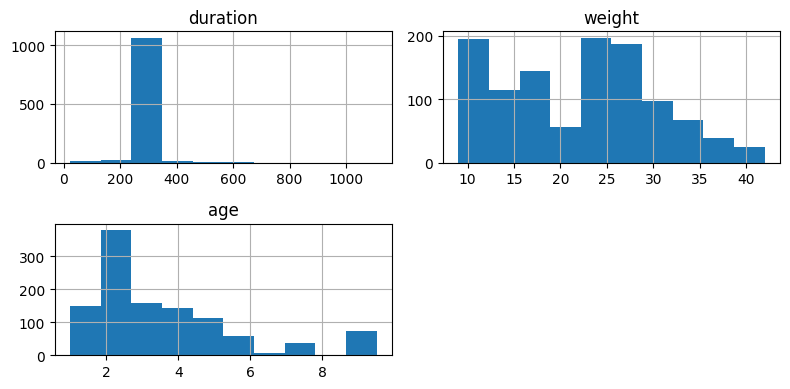

In [5]:
### Histogramas de las variables numéricas

df[["duration", "weight", "age"]].hist(figsize=(8,4))
plt.tight_layout()
plt.show()

In [6]:
### Seleccionar features y target

features = ["duration", "weight", "age", "breeds"]
target = "bad_ecg"

X = df[features]
y = df[target]

In [7]:
### Preprocesamiento

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [8]:
numeric_features = ["duration", "weight", "age"]
categorical_features = ["breeds"]

In [9]:
### Crear pipeline de preprocesado + modelo

from sklearn.ensemble import RandomForestClassifier

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

In [10]:
df["bad_ecg"].value_counts()

bad_ecg
[]                                                    675
[(2.0, 28.0)]                                          23
[(2.0, 298.1462)]                                      18
[(54.0, 80.0)]                                         16
[(2.0, 54.0)]                                          15
                                                     ... 
[(2.0, 54.0), (184.0, 236.0)]                           1
[(80.0, 262.0)]                                         1
[(54.0, 106.0), (132.0, 210.0), (262.0, 298.1231)]      1
[(28.0, 54.0), (158.0, 184.0)]                          1
[(80.0, 184.0), (210.0, 298.1846)]                      1
Name: count, Length: 227, dtype: int64

In [11]:
df["bad_ecg"].value_counts(normalize=True)

bad_ecg
[]                                                    0.601069
[(2.0, 28.0)]                                         0.020481
[(2.0, 298.1462)]                                     0.016028
[(54.0, 80.0)]                                        0.014248
[(2.0, 54.0)]                                         0.013357
                                                        ...   
[(2.0, 54.0), (184.0, 236.0)]                         0.000890
[(80.0, 262.0)]                                       0.000890
[(54.0, 106.0), (132.0, 210.0), (262.0, 298.1231)]    0.000890
[(28.0, 54.0), (158.0, 184.0)]                        0.000890
[(80.0, 184.0), (210.0, 298.1846)]                    0.000890
Name: proportion, Length: 227, dtype: float64

In [12]:
### Crear el target binario bad_ecg_binary

import ast

def convert_bad_ecg(x):
    try:
        lst = ast.literal_eval(x)
        return 1 if len(lst) > 0 else 0
    except:
        return 0

df["bad_ecg_binary"] = df["bad_ecg"].apply(convert_bad_ecg)

In [13]:
df["bad_ecg_binary"].value_counts()

bad_ecg_binary
0    675
1    448
Name: count, dtype: int64

In [14]:
df["bad_ecg_binary"].value_counts(normalize=True)

bad_ecg_binary
0    0.601069
1    0.398931
Name: proportion, dtype: float64

In [15]:
target = "bad_ecg_binary"

In [16]:
features = ["duration", "weight", "age", "breeds"]
target = "bad_ecg_binary"   

X = df[features]
y = df[target]

print(y.value_counts())
print(y.value_counts(normalize=True))

bad_ecg_binary
0    675
1    448
Name: count, dtype: int64
bad_ecg_binary
0    0.601069
1    0.398931
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
### Preprocesamiento (numéricas + categórica)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

numeric_features = ["duration", "weight", "age"]
categorical_features = ["breeds"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

In [19]:
### Entrenar el modelo

clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [20]:
### Evaluación del modelo

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predicciones
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Métricas
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.73      0.72       135
           1       0.58      0.54      0.56        90

    accuracy                           0.66       225
   macro avg       0.64      0.64      0.64       225
weighted avg       0.65      0.66      0.66       225

ROC-AUC: 0.6955555555555557

Confusion Matrix:
[[99 36]
 [41 49]]


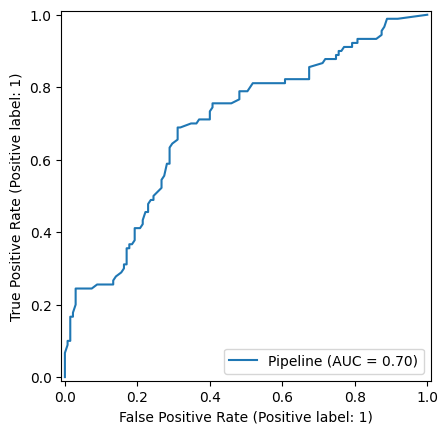

In [21]:
### Curva ROC

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.show()

In [22]:
### MEJORA: Añadir features derivados de la señal
## Parsear las columnas complejas a objetos de Python

import ast
import numpy as np

def safe_eval_list(x):
    """
    Convierte un string tipo '[...]' en una lista de Python.
    Devuelve [] si no se puede parsear.
    """
    if isinstance(x, str) and x.strip() != "":
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return val
        except:
            pass
    return []


In [23]:
## Crear features a partir de segments_br y segments_hr

def seg_stats(seg_list):
    """
    seg_list: lista de dicts con keys 'deb', 'fin', 'value'
    devuelve: (num_segments, total_duration, mean_value)
    """
    if not seg_list:
        return 0, 0.0, 0.0
    
    durations = []
    values = []
    for d in seg_list:
        try:
            deb = float(d.get("deb", 0.0))
            fin = float(d.get("fin", deb))
            durations.append(max(0.0, fin - deb))
            values.append(float(d.get("value", 0.0)))
        except Exception:
            continue
    
    num_segments = len(durations)
    total_duration = float(np.sum(durations)) if durations else 0.0
    mean_value = float(np.mean(values)) if values else 0.0
    return num_segments, total_duration, mean_value

In [24]:
## Crear las columnas segments_br_parsed, segments_hr_parsed, ecg_pulses_parsed

import ast
import numpy as np

def safe_to_list(x):
    """
    Convierte el valor a lista de Python:
    - si ya es lista, la devuelve tal cual
    - si es string tipo '[...]', lo parsea
    - si no, devuelve []
    """
    if isinstance(x, list):
        return x
    if isinstance(x, str) and x.strip() != "":
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass
    return []

for col in ["segments_br", "segments_hr", "ecg_pulses"]:
    new_col = col + "_parsed"
    df[new_col] = df[col].apply(safe_to_list)

df[["segments_br_parsed", "segments_hr_parsed", "ecg_pulses_parsed"]].head()


,segments_br_parsed,segments_hr_parsed,ecg_pulses_parsed
0,"[{'deb': 200.0, 'fin': 240.0, 'value': 13.24}]",[],"[0.98, 2.51, 2.82, 3.39, 4.04, 4.65, 5.57, 6.5..."
1,"[{'deb': 240.0, 'fin': 280.0, 'value': 12.34},...",[],"[0.64, 1.28, 2.06, 2.37, 2.79, 3.7, 4.41, 5.3,..."
2,"[{'deb': 210.0, 'fin': 250.0, 'value': 12.01},...","[{'deb': 90.0, 'fin': 110.0, 'value': 56.39}, ...","[0.93, 1.14, 1.94, 2.95, 3.82, 4.44, 5.02, 6.3..."
3,"[{'deb': 50.0, 'fin': 90.0, 'value': 13.13}]","[{'deb': 240.0, 'fin': 260.0, 'value': 52.43},...","[0.83, 1.84, 2.62, 3.33, 5.25, 6.9, 7.77, 8.43..."
4,"[{'deb': 100.0, 'fin': 140.0, 'value': 13.99}]","[{'deb': 250.0, 'fin': 270.0, 'value': 46.81},...","[1.18, 2.33, 3.75, 5.42, 6.6, 7.76, 8.84, 9.94..."


In [25]:
## Estadísticas de respiración y HR

def seg_stats(seg_list):
    """
    seg_list: lista de dicts con 'deb', 'fin', 'value'
    devuelve: (num_segments, total_duration, mean_value)
    """
    if not seg_list:
        return 0, 0.0, 0.0
    
    durations = []
    values = []
    for d in seg_list:
        try:
            deb = float(d.get("deb", 0.0))
            fin = float(d.get("fin", deb))
            durations.append(max(0.0, fin - deb))
            values.append(float(d.get("value", 0.0)))
        except Exception:
            continue
    
    num_segments = len(durations)
    total_duration = float(np.sum(durations)) if durations else 0.0
    mean_value = float(np.mean(values)) if values else 0.0
    return num_segments, total_duration, mean_value

# Respiración
br_stats = df["segments_br_parsed"].apply(seg_stats)
df["br_n_segments"]      = br_stats.apply(lambda x: x[0])
df["br_total_duration"]  = br_stats.apply(lambda x: x[1])
df["br_mean_value"]      = br_stats.apply(lambda x: x[2])

# Ritmo cardiaco
hr_stats = df["segments_hr_parsed"].apply(seg_stats)
df["hr_n_segments"]      = hr_stats.apply(lambda x: x[0])
df["hr_total_duration"]  = hr_stats.apply(lambda x: x[1])
df["hr_mean_value"]      = hr_stats.apply(lambda x: x[2])

df[["br_n_segments", "br_total_duration", "hr_n_segments", "hr_total_duration"]].head()

,br_n_segments,br_total_duration,hr_n_segments,hr_total_duration
0,1,40.00,0,0.0
1,18,720.00,0,0.0
2,4,160.32,11,220.0
3,1,40.00,7,140.0
4,1,40.00,4,80.0


In [26]:
## Pulsos 

def pulse_stats(pulse_list, duration):
    if not pulse_list or duration is None or duration == 0:
        return 0, 0.0
    try:
        count = len(pulse_list)
        density = count / float(duration)
        return count, density
    except Exception:
        return 0, 0.0

pulse_info = df.apply(
    lambda row: pulse_stats(row["ecg_pulses_parsed"], row["duration"]),
    axis=1
)

df["pulses_count"]   = pulse_info.apply(lambda x: x[0])
df["pulses_density"] = pulse_info.apply(lambda x: x[1])

df[["pulses_count", "pulses_density"]].head()

,pulses_count,pulses_density
0,380,1.266160
1,328,1.093042
2,292,0.973074
3,275,0.916239
4,306,1.019592


In [27]:
### Entrenar el modelo mejorado
## Definir la lista completa de features

features = [
    # Datos base
    "duration", "weight", "age",

    # Respiración
    "br_n_segments", "br_total_duration", "br_mean_value",

    # Ritmo cardiaco
    "hr_n_segments", "hr_total_duration", "hr_mean_value",

    # Pulsos
    "pulses_count", "pulses_density",

    # Categórica
    "breeds"
]

target = "bad_ecg_binary"

X = df[features]
y = df[target]

X.head()

,duration,weight,age,br_n_segments,br_total_duration,br_mean_value,hr_n_segments,hr_total_duration,hr_mean_value,pulses_count,pulses_density,breeds
0,300.12,34.0,4.5,1,40.00,13.240,0,0.0,0.000000,380,1.266160,boxer
1,300.08,34.0,4.5,18,720.00,12.915,0,0.0,0.000000,328,1.093042,boxer
2,300.08,34.0,4.5,4,160.32,13.545,11,220.0,54.567273,292,0.973074,boxer
3,300.14,34.0,4.5,1,40.00,13.130,7,140.0,51.894286,275,0.916239,boxer
4,300.12,34.0,4.5,1,40.00,13.990,4,80.0,49.907500,306,1.019592,boxer


In [28]:
## Train/test split (con estratificación)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
## Preprocesamiento (numéricas + categórica)

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = [
    "duration", "weight", "age",
    "br_n_segments", "br_total_duration", "br_mean_value",
    "hr_n_segments", "hr_total_duration", "hr_mean_value",
    "pulses_count", "pulses_density"
]

categorical_features = ["breeds"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [30]:
## Modelo

from sklearn.ensemble import RandomForestClassifier

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

In [31]:
## Entrenar

clf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       135
           1       0.81      0.70      0.75        90

    accuracy                           0.81       225
   macro avg       0.81      0.79      0.80       225
weighted avg       0.81      0.81      0.81       225

ROC-AUC: 0.8893415637860081

Confusion Matrix:
[[120  15]
 [ 27  63]]


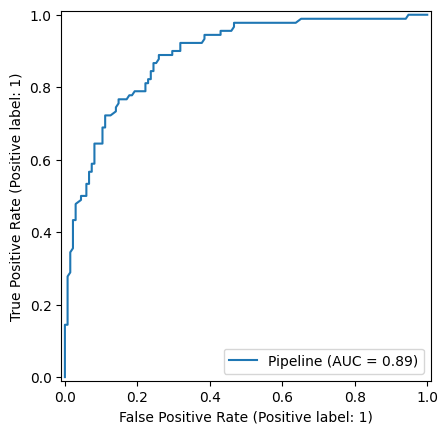

In [32]:
## Evaluar

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

RocCurveDisplay.from_estimator(clf, X_test, y_test)
plt.show()

In [33]:
### Optimizar el modelo
## RandomizedSearchCV sobre el RandomForest del pipeline

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

param_distributions = {
    "model__n_estimators": [200, 300, 400, 600, 800],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": [None, "balanced"]
}

In [35]:
## Lanzar RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_distributions,
    n_iter=30,            # puedes subir a 50 si quieres
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [36]:
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)
print("\nMejor ROC-AUC en CV:", random_search.best_score_)

Mejores hiperparámetros encontrados:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 15, 'model__class_weight': None}

Mejor ROC-AUC en CV: 0.8889294615429201


Classification Report (mejor modelo):

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       135
           1       0.79      0.73      0.76        90

    accuracy                           0.81       225
   macro avg       0.81      0.80      0.80       225
weighted avg       0.81      0.81      0.81       225

ROC-AUC (mejor modelo): 0.8874074074074074

Confusion Matrix (mejor modelo):
[[117  18]
 [ 24  66]]


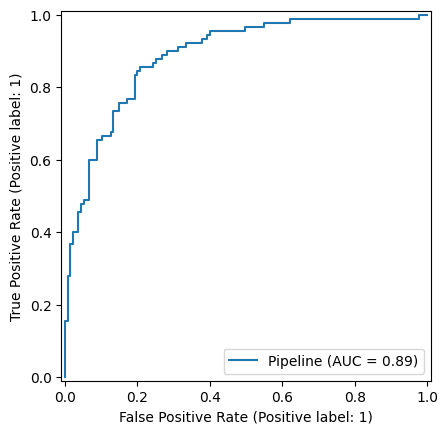

In [37]:
## Evaluar el mejor modelo en el test set

best_clf = random_search.best_estimator_

y_pred_best = best_clf.predict(X_test)
y_proba_best = best_clf.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

print("Classification Report (mejor modelo):\n")
print(classification_report(y_test, y_pred_best))

print("ROC-AUC (mejor modelo):", roc_auc_score(y_test, y_proba_best))

print("\nConfusion Matrix (mejor modelo):")
print(confusion_matrix(y_test, y_pred_best))

RocCurveDisplay.from_estimator(best_clf, X_test, y_test)
plt.show()

In [ ]:
### Interpretabilidad SHAP

In [38]:
import shap
shap.initjs()

C:\Proyectos\pet-ecg-quality-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
## Preparar datos transformados y nombres de variables

# Datos ya divididos
# X_train, X_test, y_train, y_test

preprocessor = best_clf.named_steps["preprocessor"]
model = best_clf.named_steps["model"]

# Transformar los datos
X_train_trans = preprocessor.transform(X_train)
X_test_trans  = preprocessor.transform(X_test)

# Obtener nombres de las columnas transformadas
# (numéricas + one-hot de 'breeds')
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]

numeric_features = [
    "duration", "weight", "age",
    "br_n_segments", "br_total_duration", "br_mean_value",
    "hr_n_segments", "hr_total_duration", "hr_mean_value",
    "pulses_count", "pulses_density"
]
categorical_features = ["breeds"]

cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = list(numeric_features) + list(cat_feature_names)

X_train_trans.shape, len(feature_names)

((898, 36), 36)

In [40]:
## Calcular SHAP values


best_clf = random_search.best_estimator_

# Asegurarnos de que está entrenado 
best_clf.fit(X_train, y_train)

# Extraer preprocessor y modelo entrenado
preprocessor = best_clf.named_steps["preprocessor"]
model = best_clf.named_steps["model"]

# Transformar X_train y X_test
X_train_trans = preprocessor.transform(X_train)
X_test_trans  = preprocessor.transform(X_test)

In [41]:
type(model), hasattr(model, "estimators_")

(sklearn.ensemble._forest.RandomForestClassifier, True)

In [42]:
## Crear el explainer SHAP

import shap
shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans)

# Clase 1 (ECG malo)
sv1 = shap_values[1]

print("SHAP shape:", sv1.shape)
print("X_test_trans shape:", X_test_trans.shape)

SHAP shape: (36, 2)
X_test_trans shape: (225, 36)


In [43]:
if sv1.shape[1] > X_test_trans.shape[1]:
    sv1 = sv1[:, :X_test_trans.shape[1]]

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Recuperar preprocessor y modelo
preprocessor = best_clf.named_steps["preprocessor"]
model = best_clf.named_steps["model"]

numeric_features = [
    "duration", "weight", "age",
    "br_n_segments", "br_total_duration", "br_mean_value",
    "hr_n_segments", "hr_total_duration", "hr_mean_value",
    "pulses_count", "pulses_density"
]
categorical_features = ["breeds"]

# 2. Obtener nombres de columnas finales (num + one-hot de breeds)
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = list(numeric_features) + list(cat_feature_names)

# 3. Importancias del RandomForest
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(20)

,feature,importance
6,hr_n_segments,0.147429
7,hr_total_duration,0.140280
9,pulses_count,0.104727
10,pulses_density,0.096892
8,hr_mean_value,0.080563
1,weight,0.072689
5,br_mean_value,0.063434
4,br_total_duration,0.056380
0,duration,0.055175
3,br_n_segments,0.046862


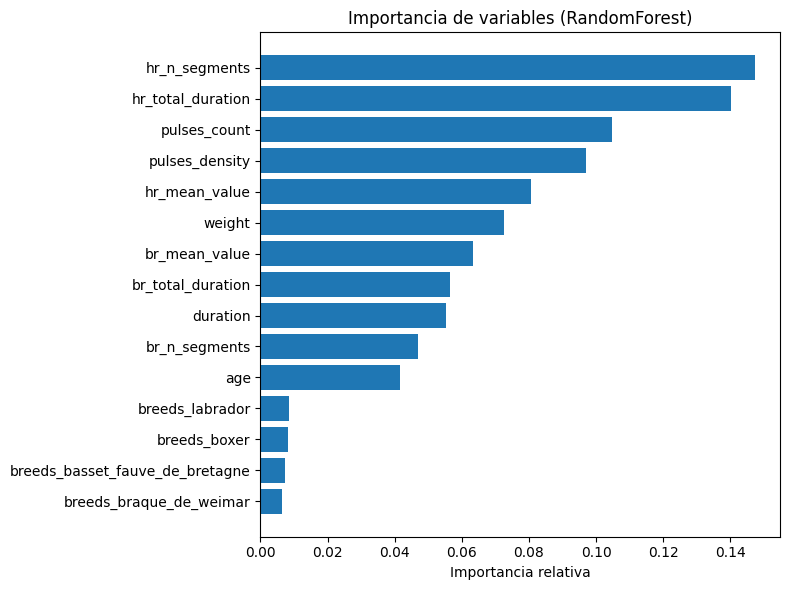

In [45]:
top_n = 15  

top_feat_imp = feat_imp.head(top_n).iloc[::-1]  # al revés para que salga ordenado de abajo arriba

plt.figure(figsize=(8, 6))
plt.barh(top_feat_imp["feature"], top_feat_imp["importance"])
plt.title("Importancia de variables (RandomForest)")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

In [46]:
## Permutation importance

from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_clf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc"
)

perm_imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

perm_imp.head(15)

,feature,importance_mean,importance_std
7,hr_total_duration,0.053722,0.015469
6,hr_n_segments,0.049173,0.015957
9,pulses_count,0.030002,0.006619
1,weight,0.019996,0.010558
8,hr_mean_value,0.014862,0.005960
10,pulses_density,0.013481,0.005259
0,duration,0.010138,0.003106
11,breeds,0.009374,0.004353
2,age,0.008749,0.004023
3,br_n_segments,0.006255,0.004049


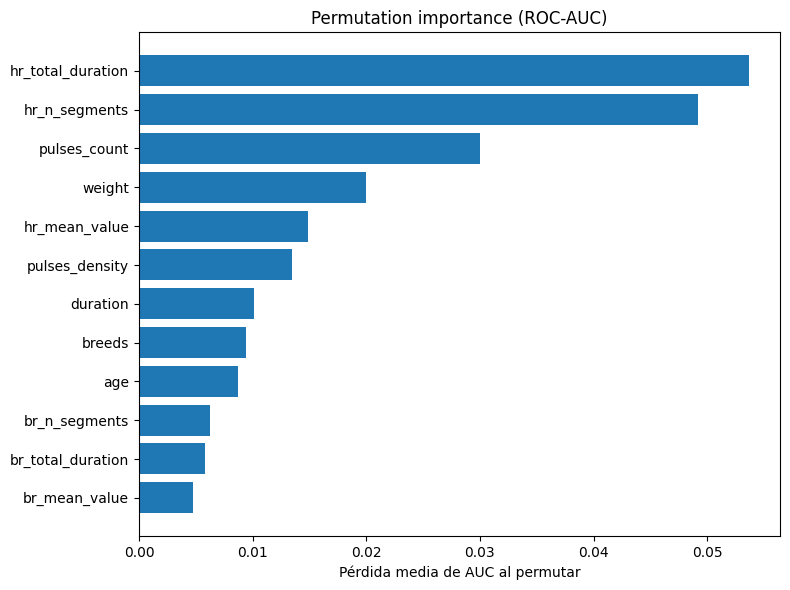

In [47]:
top_perm = perm_imp.head(15).iloc[::-1]

plt.figure(figsize=(8,6))
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title("Permutation importance (ROC-AUC)")
plt.xlabel("Pérdida media de AUC al permutar")
plt.tight_layout()
plt.show()